In [3]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp
import jaxquantum as jqt

from gkp_optimal_control.plotting import (
    plot_photon_number,
    plot_wigner,
    set_plot_style,
)
from gkp_optimal_control.states import cat_states, gkp_states, gkp_states_new
from gkp_optimal_control.utils import compute_wigner

set_plot_style()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
n_fock = 300
a = jqt.destroy(n_fock)

q = (1 / np.sqrt(2)) * (a + a.dag())
p = (1j / np.sqrt(2)) * (a.dag() - a)

n = 1


def cosm_herm(Aqobj):
    w, V = np.linalg.eigh(Aqobj.full())
    M = (V * np.cos(w)) @ V.conj().T
    return jqt.Qarray(M)


cos_p = cosm_herm(2 * np.sqrt(np.pi) * p)
cos_q = cosm_herm(2 * np.sqrt(np.pi) * q)

In [74]:
ham = 2 - (cos_p + cos_q)
evals, evecs = ham.eigenstates(eigvals=6)

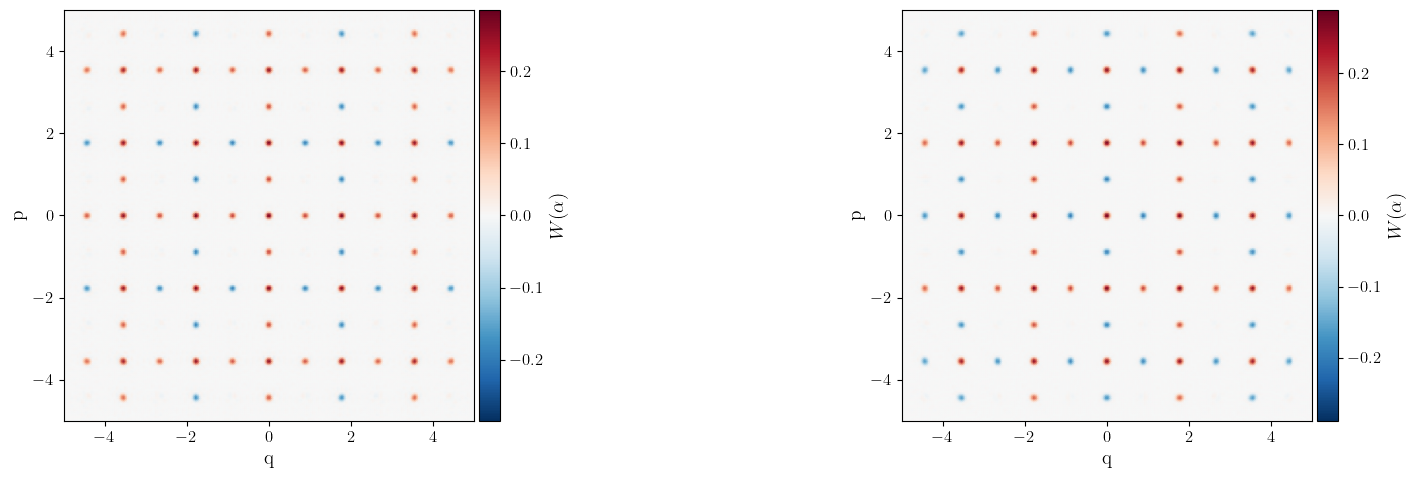

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plot_wigner(evecs[0], x_bound=5, y_bound=5, ax=axes[0])
plot_wigner(evecs[1], x_bound=5, y_bound=5, ax=axes[1])
# plot_wigner(evecs[2], x_bound=5, y_bound=5, ax=axes[0, 2])
# plot_wigner(evecs[3], x_bound=5, y_bound=5, ax=axes[1, 0])
# plot_wigner(evecs[4], x_bound=5, y_bound=5, ax=axes[1, 1])
# plot_wigner(evecs[5], x_bound=5, y_bound=5, ax=axes[1, 2])

fig.tight_layout()
plt.show()

In [76]:
print(evals)

[0.04441715 0.04997876 0.12029927 0.12254542 0.13124405 0.13822476]


In [66]:
S_q = (1j * 2 * np.pi * n * q).expm()
S_p = (1j * p).expm()
psi = evecs[0]
print("⟨S_q⟩ =", (psi.dag() * S_q * psi).tr())
print("⟨S_p⟩ =", (psi.dag() * S_p * psi).tr())

AttributeError: 'complex' object has no attribute 'tr'